In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
url = "https://raw.githubusercontent.com/Sahdam/TS_Academy_Capstone_Project/refs/heads/main/Model_Data_set.csv"

df = pd.read_csv(url, parse_dates=["Date"], index_col="Date")
df.head()

,food_cpi,fuel_price,exchange_rate,basket_cost
Date,,,,
2017-01-31,221.4,148.70,305.20,17028.51
2017-02-28,225.8,149.80,305.31,17171.78
2017-03-31,230.8,149.39,306.40,17846.54
2017-04-30,235.5,149.87,306.05,18087.17
2017-05-31,241.5,150.69,305.54,18632.75


In [3]:
df = df.asfreq(freq="ME")

In [4]:
df.tail()

,food_cpi,fuel_price,exchange_rate,basket_cost
Date,,,,
2025-09-30,1220.32,970.59,1503.64,95288.57
2025-10-31,1216.49,1052.31,1465.09,94834.85
2025-11-30,1229.91,1061.35,1444.58,93900.94
2025-12-31,1225.12,1048.63,1452.54,93900.94
2026-01-31,1151.30,795.00,1419.98,93900.94


In [264]:
train_end = "2025-09-30"
test_start ="2025-10-31"
test_end = "2026-01-31"

In [265]:
train = df.loc[:train_end]
test = df.loc[test_start:test_end]

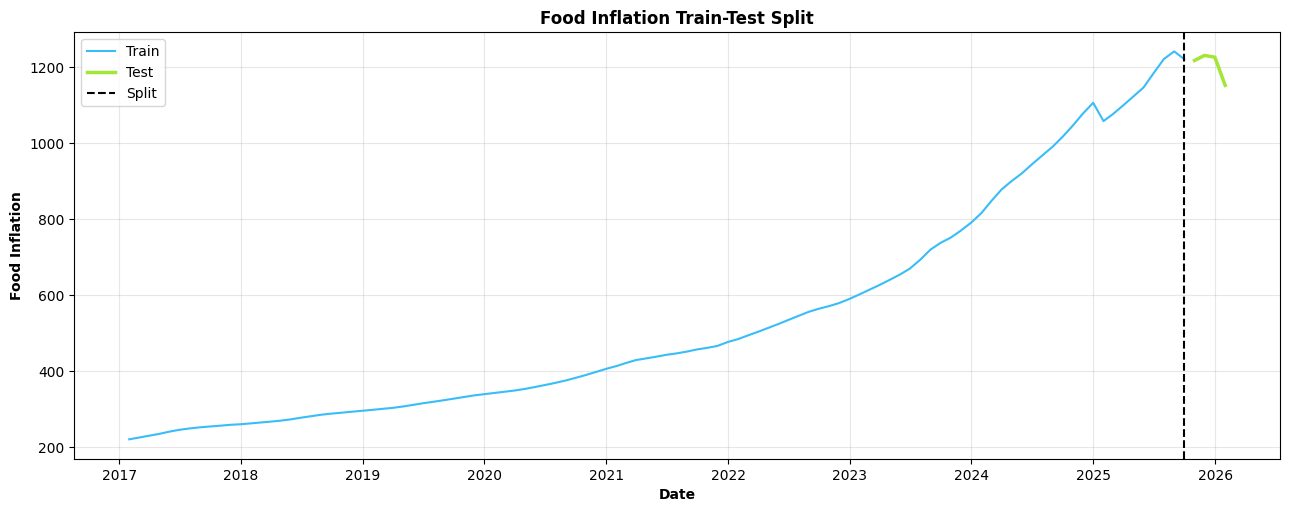

In [266]:
plt.figure(figsize=(13,5))
plt.plot(train['food_cpi'], color='#38bdf8',label="Train")
plt.plot(test['food_cpi'],  color='#a3e635', linewidth=2.5, label='Test')
plt.axvline(x=train.index[-1], linestyle="--", color="black", label="Split")
plt.xlabel("Date", fontweight='bold')
plt.ylabel("Food Inflation", fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.title('Food Inflation Train-Test Split', fontweight='bold')
plt.legend()
plt.savefig("train_test_spit_food", dpi=150, bbox_inches='tight')
plt.show()

In [267]:
from statsmodels.tsa.arima.model import ARIMA
food_arima = ARIMA(train['food_cpi'], order=(1,2,1)).fit()
food_arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               food_cpi   No. Observations:                  105
Model:                 ARIMA(1, 2, 1)   Log Likelihood                -376.936
Date:                Sun, 08 Mar 2026   AIC                            759.872
Time:                        23:08:00   BIC                            767.776
Sample:                    01-31-2017   HQIC                           763.073
                         - 09-30-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1797      0.091      1.986      0.047       0.002       0.357
ma.L1         -0.8947      0.080    -11.225      0.000      -1.051      -0.738
sigma2        87.2406      8.533     10.224      0.000      70.516     103.965
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              7407.51
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):             320.77   Skew:                            -5.58
Prob(H) (two-sided):                  0.00   Kurtosis:                        43.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [268]:
forecast_result_food = food_arima.get_forecast(steps=len(test))
food_forecast_1 = forecast_result_food.predicted_mean
food_arima_ci = forecast_result_food.conf_int(alpha=0.05)
food_forecast_1

,predicted_mean
2025-10-31,1230.249172
2025-11-30,1245.580566
2025-12-31,1261.882846
2026-01-31,1278.359612


In [269]:
food_arima_ci

,lower food_cpi,upper food_cpi
2025-10-31,1211.942583,1248.555762
2025-11-30,1215.772459,1275.388674
2025-12-31,1222.071576,1301.694115
2026-01-31,1229.204381,1327.514842


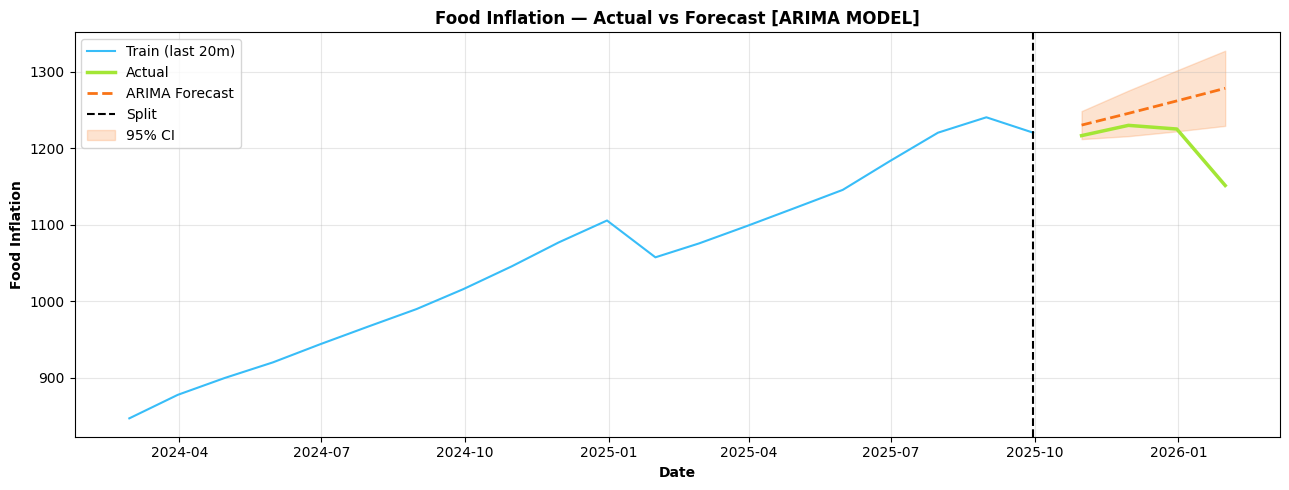

In [270]:
plt.figure(figsize=(13,5))
plt.plot(train['food_cpi'].iloc[-20:], color='#38bdf8', label='Train (last 20m)')
plt.plot(test['food_cpi'],color='#a3e635', linewidth=2.5, label='Actual')
plt.plot(food_forecast_1, color='#f97316', linestyle='--', linewidth=2, label='ARIMA Forecast')
plt.axvline(x=train.index[-1], linestyle="--", color="black", label="Split")
plt.xlabel("Date", fontweight='bold')
plt.ylabel("Food Inflation", fontweight='bold')
plt.title('Food Inflation — Actual vs Forecast [ARIMA MODEL]', fontweight='bold')
plt.fill_between(food_arima_ci.index,
                 food_arima_ci.iloc[:, 0],
                 food_arima_ci.iloc[:, 1],
                 alpha=0.2, color='#f97316', label='95% CI')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("Arima_forecast_food", dpi=150, bbox_inches='tight')
plt.show()

In [271]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
food_cost_sarimax = SARIMAX(train['food_cpi'], order=(1,2,1), seasonal_order=(0,1,0,12)).fit()
food_cost_sarimax.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                            food_cpi   No. Observations:                  105
Model:             SARIMAX(1, 2, 1)x(0, 1, [], 12)   Log Likelihood                -343.795
Date:                             Sun, 08 Mar 2026   AIC                            693.590
Time:                                     23:08:02   BIC                            701.123
Sample:                                 01-31-2017   HQIC                           696.629
                                      - 09-30-2025                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3571      0.108      3.322      0.001       0.146       0.568
ma.L1         -0.9994      1.549     -0.645      0.519      -4.035       2.036
sigma2       107.4069    172.005      0.624      0.532    -229.717     444.531
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              5938.54
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):             385.09   Skew:                            -5.71
Prob(H) (two-sided):                  0.00   Kurtosis:                        40.89
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [272]:
forecast_2 = food_cost_sarimax.get_forecast(steps=len(test))
food_forecast_2 = forecast_2.predicted_mean
food_sarimax_ci = forecast_2.conf_int(alpha=0.05)
food_forecast_2

,predicted_mean
2025-10-31,1234.549080
2025-11-30,1261.125706
2025-12-31,1289.111411
2026-01-31,1241.652944


In [273]:
food_sarimax_ci

,lower food_cpi,upper food_cpi
2025-10-31,1214.134170,1254.963990
2025-11-30,1226.537502,1295.713909
2025-12-31,1242.787368,1335.435454
2026-01-31,1185.316563,1297.989326


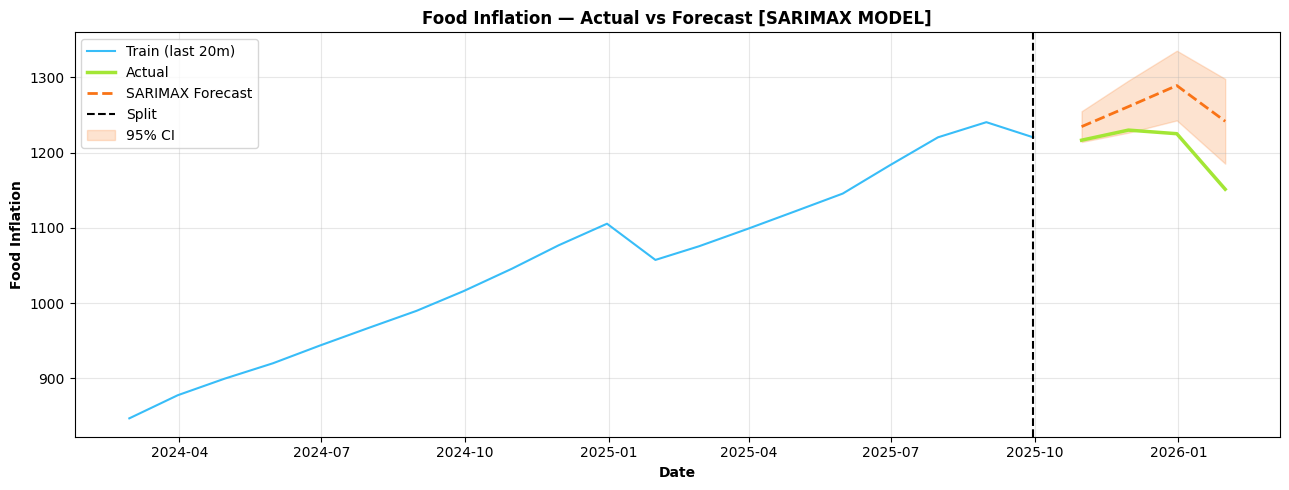

In [274]:
plt.figure(figsize=(13,5))
plt.plot(train['food_cpi'].iloc[-20:], color='#38bdf8', label='Train (last 20m)')
plt.plot(test['food_cpi'],color='#a3e635', linewidth=2.5, label='Actual')
plt.plot(food_forecast_2, color='#f97316', linestyle='--', linewidth=2, label='SARIMAX Forecast')
plt.axvline(x=train.index[-1], linestyle="--", color="black", label="Split")
plt.xlabel("Date", fontweight='bold')
plt.ylabel("Food Inflation", fontweight='bold')
plt.title('Food Inflation — Actual vs Forecast [SARIMAX MODEL]', fontweight='bold')
plt.fill_between(food_sarimax_ci.index,
                 food_sarimax_ci.iloc[:, 0],
                 food_sarimax_ci.iloc[:, 1],
                 alpha=0.2, color='#f97316', label='95% CI')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("Sarima_forecast_food", dpi=150, bbox_inches='tight')
plt.show()

In [275]:
food_exog = ['fuel_price', "exchange_rate", "basket_cost"]

food_sarimax_exog = SARIMAX(train['food_cpi'],
                              exog=train[food_exog],
                              order=(1,2,1),
                              seasonal_order=(0,1,0,12),
                              enforce_invertibility=False,
                              enforce_stationarity=False).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [276]:
forecast_3 = food_sarimax_exog.get_forecast(steps=len(test), exog=test[food_exog])
food_forecast_3 = forecast_3.predicted_mean
food_sarimax_exog_ci = forecast_3.conf_int(alpha=0.05)

food_forecast_3

,predicted_mean
2025-10-31,1230.433033
2025-11-30,1208.484341
2025-12-31,1215.131210
2026-01-31,1162.126072


In [277]:
food_sarimax_exog_ci

,lower food_cpi,upper food_cpi
2025-10-31,1211.829870,1249.036195
2025-11-30,1171.891559,1245.077124
2025-12-31,1153.134685,1277.127734
2026-01-31,1073.722000,1250.530144


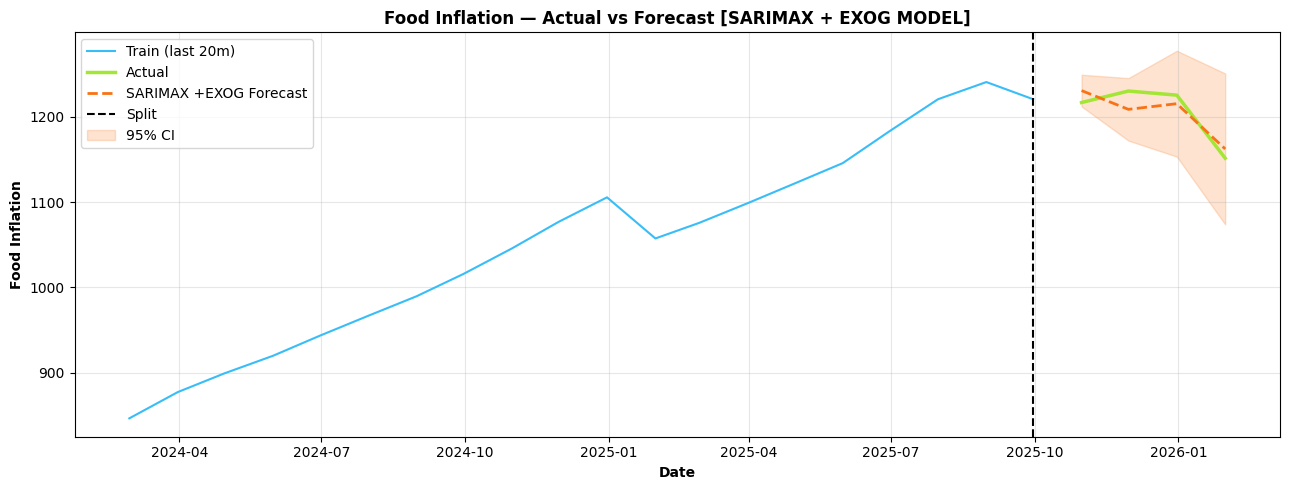

In [278]:
plt.figure(figsize=(13,5))
plt.plot(train['food_cpi'].iloc[-20:], color='#38bdf8', label='Train (last 20m)')
plt.plot(test['food_cpi'],color='#a3e635', linewidth=2.5, label='Actual')
plt.plot(food_forecast_3, color='#f97316', linestyle='--', linewidth=2, label='SARIMAX +EXOG Forecast')
plt.axvline(x=train.index[-1], linestyle="--", color="black", label="Split")
plt.xlabel("Date", fontweight='bold')
plt.ylabel("Food Inflation", fontweight='bold')
plt.title('Food Inflation — Actual vs Forecast [SARIMAX + EXOG MODEL]', fontweight='bold')
plt.fill_between(food_sarimax_exog_ci.index,
                 food_sarimax_exog_ci.iloc[:, 0],
                 food_sarimax_exog_ci.iloc[:, 1],
                 alpha=0.2, color='#f97316', label='95% CI')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("Sarima_forecast_food_exog", dpi=150, bbox_inches='tight')
plt.show()

In [279]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_forecast(test, forecast):
    mse = mean_squared_error(test, forecast)
    mae = mean_absolute_error(test, forecast)
    mape =(np.abs(test - forecast)/test).mean() * 100
    print(f"MSE = {mse:.2f} MAE={mae:.2f} MAPE={mape:.2f}%")
    return mse, mae, mape

In [280]:
actual_food_cost = test['food_cpi']
arima_forecast = food_forecast_1
sarimax_forecast = food_forecast_2
sarimax_exog_forecast = food_forecast_3

In [281]:
evaluate_forecast(actual_food_cost, arima_forecast)

MSE = 4482.63 MAE=48.31 MAPE=4.11%


(4482.633301694643, 48.313049021945346, np.float64(4.110529750155936))

In [282]:
evaluate_forecast(actual_food_cost, sarimax_forecast)

MSE = 3389.78 MAE=50.90 MAPE=4.27%


(3389.7764663543185, 50.90478517796987, np.float64(4.273438662567335))

In [283]:
evaluate_forecast(actual_food_cost, sarimax_exog_forecast)

MSE = 217.61 MAE=14.05 MAPE=1.16%


(217.6116938913013, 14.045888436912207, np.float64(1.160971555826709))

In [285]:
last_fi = df['food_cpi'].iloc[-1]

last_exog_fuel_price = df['fuel_price'].iloc[-1]
last_exog_exchange_rate = df['exchange_rate'].iloc[-1]
last_exog_basket_cost = df['basket_cost'].iloc[-1]

future_food_exog_df = pd.DataFrame({
    'fuel_price': [last_exog_fuel_price] * 12,
    'exchange_rate': [last_exog_exchange_rate] * 12,
    'basket_cost': [last_exog_basket_cost] * 12
})

forecast_future_result = food_sarimax_exog.get_forecast(steps=12, exog=future_food_exog_df)
food_cpi_future_forecast = forecast_future_result.predicted_mean
food_cpi_future_forecast_ci = forecast_future_result.conf_int(alpha=0.05)

food_cpi_future_forecast

,predicted_mean
2025-10-31,1238.225612
2025-11-30,1219.071979
2025-12-31,1225.338968
2026-01-31,1162.126072
2026-02-28,1164.668982
2026-03-31,1131.211050
2026-04-30,1146.276875
2026-05-31,1123.220450
2026-06-30,1145.167587
2026-07-31,1145.177220


In [286]:
food_cpi_future_forecast_ci

,lower food_cpi,upper food_cpi
2025-10-31,1219.622449,1256.828775
2025-11-30,1182.479196,1255.664761
2025-12-31,1163.342443,1287.335492
2026-01-31,1073.722000,1250.530144
2026-02-28,1044.437398,1284.900567
2026-03-31,978.267431,1284.154668
2026-04-30,956.157362,1336.396389
2026-05-31,895.116414,1351.324485
2026-06-30,875.211832,1415.123342
2026-07-31,832.611401,1457.743039


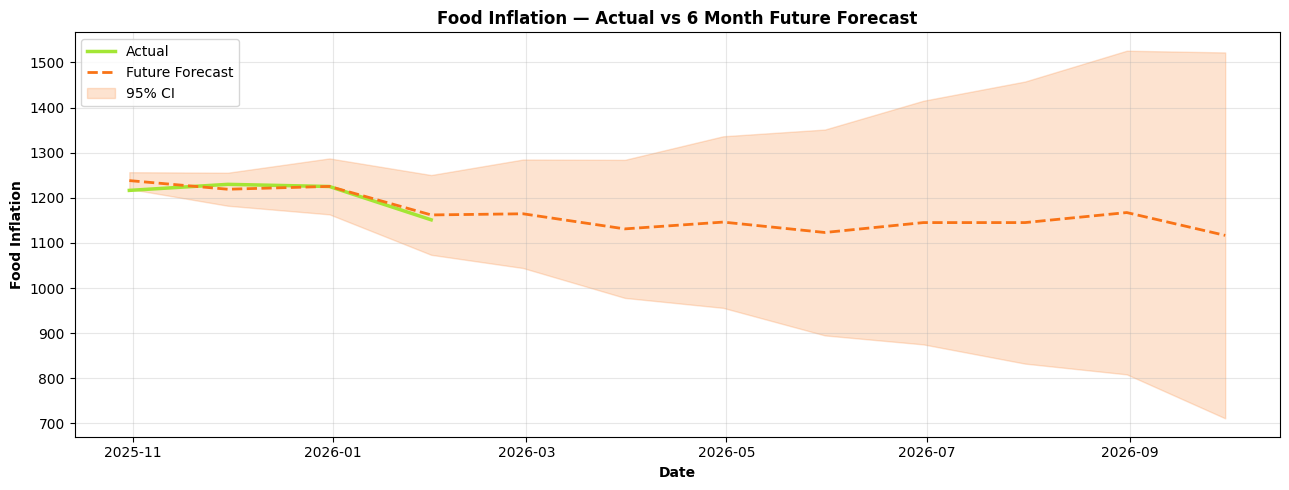

In [288]:
plt.figure(figsize=(13,5))
plt.plot(test['food_cpi'],color='#a3e635', linewidth=2.5, label='Actual')
plt.plot(food_cpi_future_forecast, color='#f97316', linestyle='--', linewidth=2, label='Future Forecast')
plt.xlabel("Date", fontweight='bold')
plt.ylabel("Food Inflation", fontweight='bold')
plt.title('Food Inflation — Actual vs 6 Month Future Forecast', fontweight='bold')
plt.fill_between(food_cpi_future_forecast_ci.index,
                 food_cpi_future_forecast_ci.iloc[:, 0],
                 food_cpi_future_forecast_ci.iloc[:, 1],
                 alpha=0.2, color='#f97316', label='95% CI')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("future_food", dpi=150, bbox_inches='tight')
plt.show()

In [289]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 16.0 MB/s eta 0:00:00


In [291]:
from arch import arch_model
from statsmodels.stats.diagnostic import het_arch


residuals_food = food_sarimax_exog.resid.dropna()


residuals_scaled = residuals_food / 1000

arch_lm_stat, arch_lm_pvalue, _, _ = het_arch(residuals_scaled, nlags=12)

print("ARCH-LM Test for Heteroskedasticity \n")

print(f"Test Statistic : {arch_lm_stat:.4f}")
print(f"P-value        : {arch_lm_pvalue:.4f}")
print()
if arch_lm_pvalue < 0.05:
    print("ARCH effects detected (p < 0.05)")
    print("   Residual variance is NOT constant — GARCH is justified")
else:
    print("No significant ARCH effects at 5% level")
    print("   GARCH may add limited value for this series")

ARCH-LM Test for Heteroskedasticity 

Test Statistic : 63.4942
P-value        : 0.0000

ARCH effects detected (p < 0.05)
   Residual variance is NOT constant — GARCH is justified


In [292]:
from statsmodels.graphics.tsaplots import plot_acf

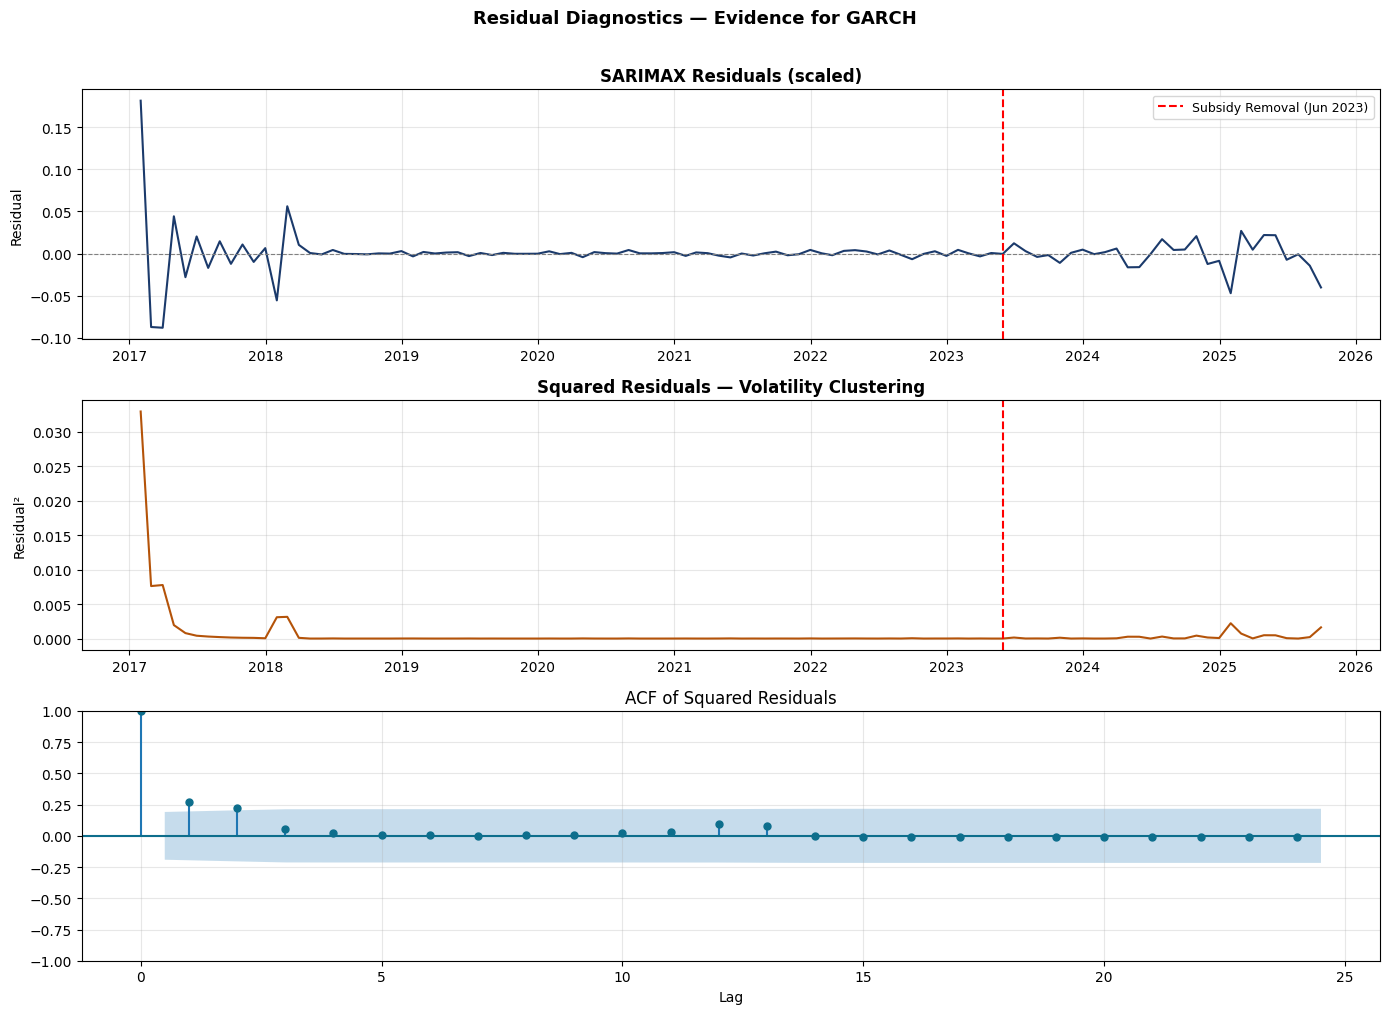

In [293]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))


axes[0].plot(residuals_food.index, residuals_scaled.values,
             color='#1B3A6B', linewidth=1.5)
axes[0].axhline(0, color='grey', linestyle='--', linewidth=0.8)
axes[0].axvline(pd.Timestamp('2023-06-01'), color='red',
                linestyle='--', linewidth=1.5, label='Subsidy Removal (Jun 2023)')
axes[0].set_title('SARIMAX Residuals (scaled)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Residual')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)


axes[1].plot(residuals_food.index, residuals_scaled.values**2,
             color='#B45309', linewidth=1.5)
axes[1].axvline(pd.Timestamp('2023-06-01'), color='red',
                linestyle='--', linewidth=1.5)
axes[1].set_title('Squared Residuals — Volatility Clustering', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Residual²')
axes[1].grid(alpha=0.3)


plot_acf(residuals_scaled**2, lags=24, ax=axes[2],
         color='#0D6E8C', title='ACF of Squared Residuals')
axes[2].set_xlabel('Lag')
axes[2].grid(alpha=0.3)

plt.suptitle('Residual Diagnostics — Evidence for GARCH',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('garch_residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

In [294]:
garch_model_food = arch_model(
    residuals_scaled,
    vol='Garch',
    p=1,
    q=1,
    dist='t'
)

garch_result = garch_model_food.fit(disp='off')

print(garch_result.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:                337.622
Distribution:      Standardized Student's t   AIC:                          -665.244
Method:                  Maximum Likelihood   BIC:                          -651.974
                                              No. Observations:                  105
Date:                      Sun, Mar 08 2026   Df Residuals:                      104
Time:                              23:28:34   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
m

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.000636. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


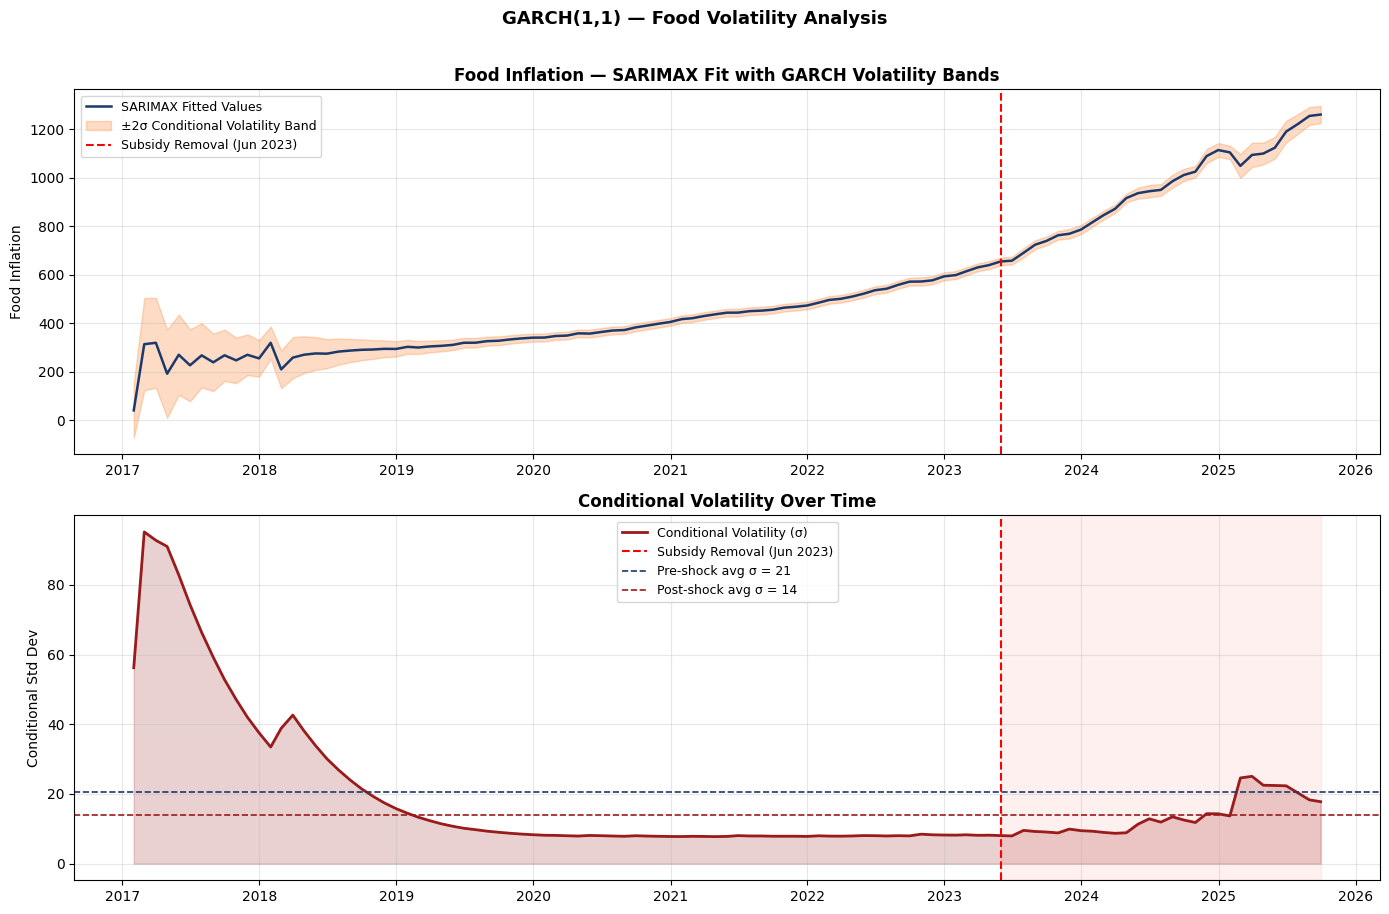


Pre-shock average conditional volatility  : 21/month
Post-shock average conditional volatility : 14/month
Volatility increase factor                : 0.7×


In [296]:
conditional_vol = garch_result.conditional_volatility * 1000  # rescale back

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

shock_date = pd.Timestamp('2023-06-01')


fitted_values = food_sarimax_exog.fittedvalues

axes[0].plot(fitted_values.index, fitted_values.values,
             color='#1B3A6B', linewidth=1.8, label='SARIMAX Fitted Values')
axes[0].fill_between(
    fitted_values.index,
    fitted_values.values - 2 * conditional_vol.values,
    fitted_values.values + 2 * conditional_vol.values,
    alpha=0.25, color='#f97316', label='±2σ Conditional Volatility Band'
)
axes[0].axvline(shock_date, color='red', linestyle='--',
                linewidth=1.5, label='Subsidy Removal (Jun 2023)')
axes[0].set_title('Food Inflation — SARIMAX Fit with GARCH Volatility Bands',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Food Inflation')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)


axes[1].plot(conditional_vol.index, conditional_vol.values,
             color='#991B1B', linewidth=2, label='Conditional Volatility (σ)')
axes[1].fill_between(conditional_vol.index, 0, conditional_vol.values,
                     alpha=0.2, color='#991B1B')
axes[1].axvline(shock_date, color='red', linestyle='--',
                linewidth=1.5, label='Subsidy Removal (Jun 2023)')
axes[1].axvspan(shock_date, conditional_vol.index[-1],
                alpha=0.06, color='red')


pre_vol  = conditional_vol[conditional_vol.index <  shock_date].mean()
post_vol = conditional_vol[conditional_vol.index >= shock_date].mean()

axes[1].axhline(pre_vol,  color='#1B3A6B', linestyle='--', linewidth=1.2,
                label=f'Pre-shock avg σ = {pre_vol:,.0f}')
axes[1].axhline(post_vol, color='#991B1B', linestyle='--', linewidth=1.2,
                label=f'Post-shock avg σ = {post_vol:,.0f}')

axes[1].set_title('Conditional Volatility Over Time',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Conditional Std Dev')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('GARCH(1,1) — Food Volatility Analysis',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('garch_volatility_food.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPre-shock average conditional volatility  : {pre_vol:,.0f}/month")
print(f"Post-shock average conditional volatility : {post_vol:,.0f}/month")
print(f"Volatility increase factor                : {post_vol/pre_vol:.1f}×")

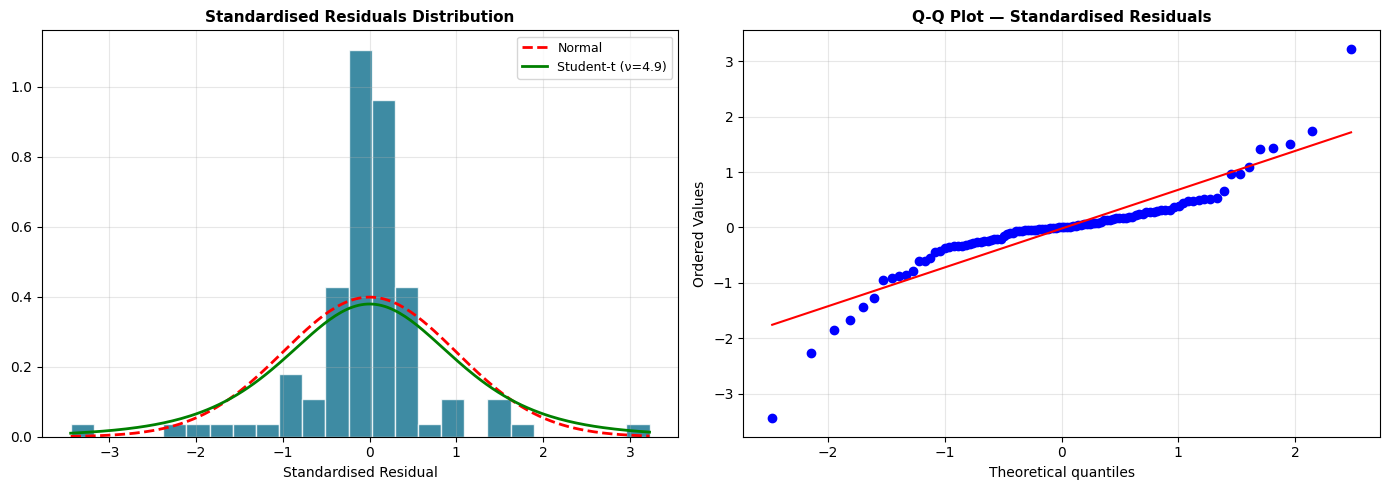

In [298]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


std_resid = garch_result.std_resid

axes[0].hist(std_resid, bins=25, color='#0D6E8C',
             edgecolor='white', alpha=0.8, density=True)


from scipy import stats
x = np.linspace(std_resid.min(), std_resid.max(), 200)
axes[0].plot(x, stats.norm.pdf(x), 'r--', linewidth=2, label='Normal')
nu = garch_result.params['nu']
axes[0].plot(x, stats.t.pdf(x, df=nu), 'g-', linewidth=2,
             label=f'Student-t (ν={nu:.1f})')
axes[0].set_title('Standardised Residuals Distribution',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Standardised Residual')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)


stats.probplot(std_resid, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot — Standardised Residuals',
                  fontsize=11, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('garch_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()